In [2]:
import pandas as pd
import librosa
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

In [9]:
def read_csv(file_path):
    df =[]
    try:
        df = pd.read_csv(file_path, header=None, names=['path', 'file', 'label','bak','task_set','task_id','merge_id'])
        df['full_route'] = df.apply(lambda row: os.path.join(row[0], row[1]), axis=1)

        durations, silent, pitch, pitch_std,rms_energy, rms_stds = [],[],[],[],[], []
        

        for path in tqdm(df['full_route']):
            try:
                y, sr = librosa.load(path, sr=None)

                #Duration
                duration = librosa.get_duration(y=y, sr=sr)
                durations.append(duration)

                #Silence
                intervals = librosa.effects.split(y, top_db=40)  # Top_db = silence threshold
                total_audio = len(y) / sr
                non_silent = sum((end - start) for start, end in intervals) / sr

                silent.append(1 - non_silent / total_audio)

                #Pitch (F0)
                try:
                    f0 = librosa.yin(y, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'), sr=sr)
                    f0_mean = np.nanmean(f0)
                    f0_std = np.nanstd(f0)
                except:
                    f0_mean = np.nan
                    f0_std = np.nan

                pitch.append(f0_mean)
                pitch_std.append(f0_std)

                #RMS energy
                rms = librosa.feature.rms(y=y)[0]
                rms_mean = np.nanmean(rms)
                rms_std = np.nanstd(rms)

                rms_energy.append(rms_mean)
                rms_stds.append(rms_std)

            except Exception as e:
                print(f"Error loading {path}: {e}")
                durations.append(None)
        df['duration'] = durations

        df['silent'] = silent
        df['pitch'] = pitch
        df['pitch_std'] = pitch_std
        df['rms_energy'] = rms_energy
        df['rms_std'] = rms_stds

        df = df.dropna(subset=['duration'])
        return df
    
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None



In [10]:
#Basic stats
def print_basic_stats(df):
    print("Number of samples: ", len(df))
    print("Number of samples per label: ")
    print(df['label'].value_counts())
    print("Average duration: ", df['duration'].mean())
    print("Median duration: ", df['duration'].median())
    print("Standard deviation of duration: ", df['duration'].std())
    print("Minimum duration: ", df['duration'].min())
    print("Maximum duration: ", df['duration'].max())

In [11]:
def compute_stats(df):
    return {
        'Mean': df.mean(),
        '50th': df.quantile(0.5),
        '75th': df.quantile(0.75),
        '90th': df.quantile(0.9),
        '95th': df.quantile(0.95),
    }

In [12]:
trainFile = 'wav_labelsTrainUpdated.csv'
df_Train = read_csv(trainFile)

C:\Users\nagap\AppData\Local\Temp\ipykernel_19636\1097469900.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df['full_route'] = df.apply(lambda row: os.path.join(row[0], row[1]), axis=1)
100%|██████████| 5400/5400 [34:24<00:00,  2.62it/s]  


Number of samples:  5400
Number of samples per label: 
label
N    3750
A    1650
Name: count, dtype: int64
Average duration:  11.675338347190728
Median duration:  6.0
Standard deviation of duration:  14.523128474764171
Minimum duration:  1.49
Maximum duration:  61.77


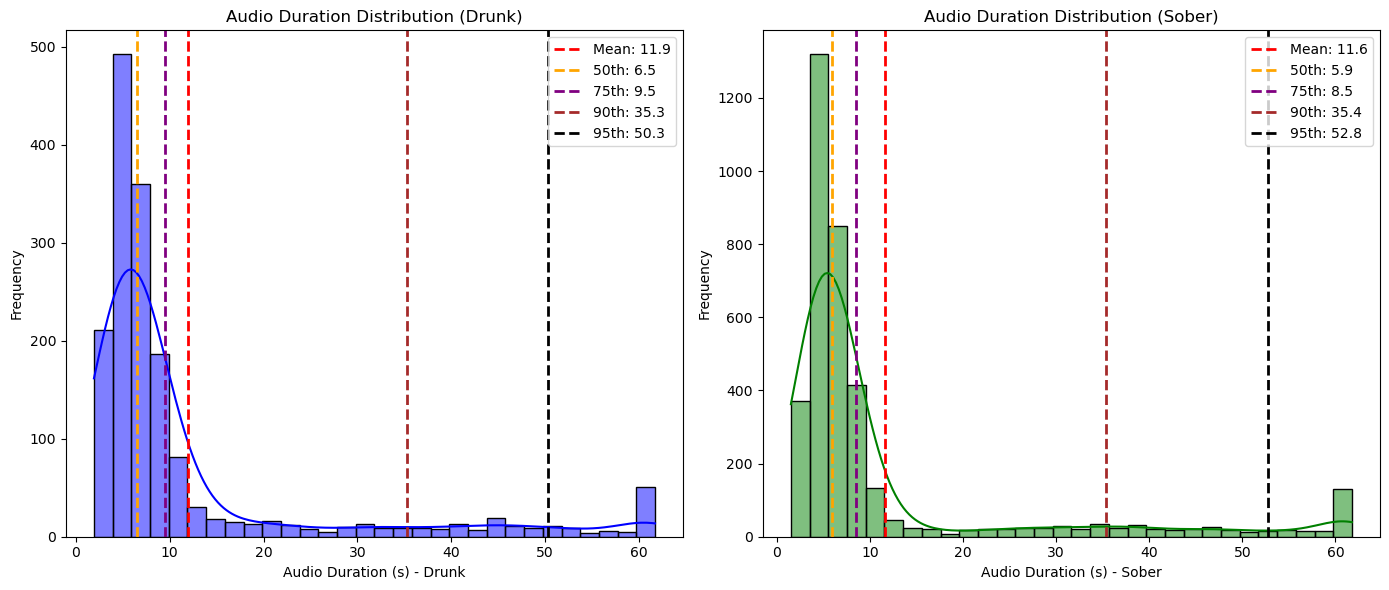

In [13]:

print_basic_stats(df_Train)
percentile_train = compute_stats(df_Train['duration'])


colors = ['red', 'orange', 'purple', 'brown', 'black']
labels = ['Mean', '50th', '75th', '90th', '95th']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

dur_A = df_Train[df_Train['label'] == 'A']['duration']
dur_N = df_Train[df_Train['label'] == 'N']['duration']

stats_trainA = compute_stats(dur_A)
stats_trainN = compute_stats(dur_N)

# Drunk
sns.histplot(dur_A, bins=30, kde=True, ax=axes[0], edgecolor='black', color='blue')
for i, key in enumerate(stats_trainA.keys()):
    axes[0].axvline(stats_trainA[key], color=colors[i], linestyle='dashed', linewidth=2, label=f"{labels[i]}: {stats_trainA[key]:.1f}")
axes[0].set_xlabel("Audio Duration (s) - Drunk")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Audio Duration Distribution (Drunk)")
axes[0].legend()

# Sober
sns.histplot(dur_N, bins=30, kde=True, ax=axes[1], edgecolor='black', color='green')
for i, key in enumerate(stats_trainN.keys()):
    axes[1].axvline(stats_trainN[key], color=colors[i], linestyle='dashed', linewidth=2, label=f"{labels[i]}: {stats_trainN[key]:.1f}")
axes[1].set_xlabel("Audio Duration (s) - Sober")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Audio Duration Distribution (Sober)")
axes[1].legend()

plt.tight_layout()
plt.show()

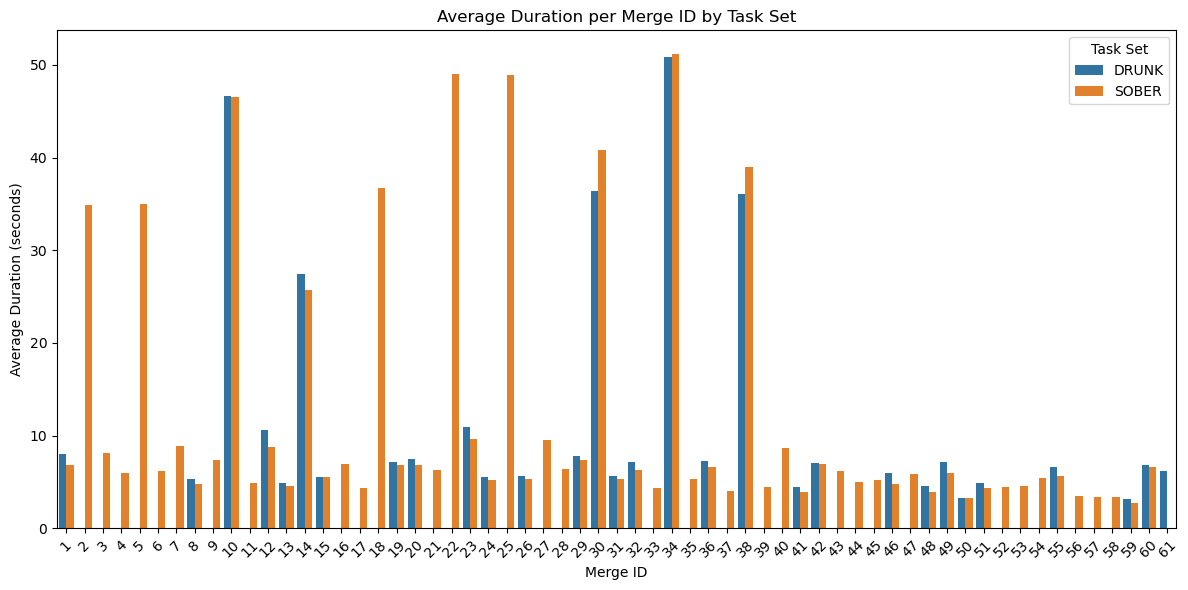

In [14]:
average_duration = df_Train.groupby(['task_set', 'merge_id'])['duration'].mean().reset_index()
average_duration.rename(columns={'duration': 'average_duration'}, inplace=True)

avg_drunk = average_duration[average_duration['task_set'] == 'DRUNK'].sort_values(by='merge_id')
avg_sober = average_duration[average_duration['task_set'] == 'SOBER'].sort_values(by='merge_id')

plt.figure(figsize=(12, 6))
sns.barplot(data=average_duration, x='merge_id', y='average_duration', hue='task_set')

plt.title("Average Duration per Merge ID by Task Set")
plt.xlabel("Merge ID")
plt.ylabel("Average Duration (seconds)")
plt.legend(title="Task Set")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

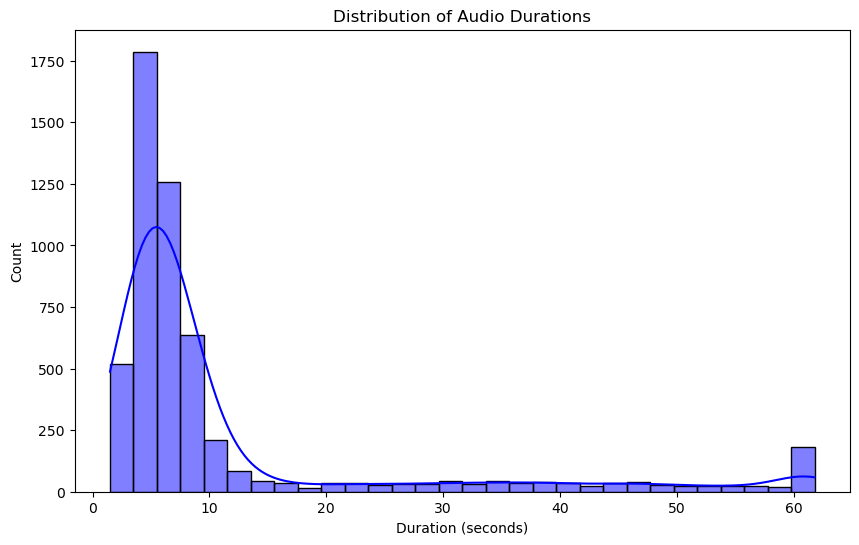

In [15]:
#Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_Train['duration'], bins=30, kde=True, edgecolor='black',color='blue')
plt.title('Distribution of Audio Durations')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.show()

In [3]:
#Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_Train['silent'], bins=30, kde=True, edgecolor='black',color='blue')
plt.title('Distribution of Silence proportion')
plt.xlabel('Silence (%)')
plt.ylabel('Count')
plt.show()

print("Minimum silence (%): ", df_Train['silent'].min())
print("Maximum silence (%): ", df_Train['silent'].max())

print(df_Train[df_Train['silent']>0.75])

plt.figure(figsize=(10, 6))
sns.histplot(data=df_Train, x='silent',
    hue='task_set', bins=30, kde=True,edgecolor='black',color='blue',    palette='Set2')

plt.title('Distribution of Silence by Task Set')
plt.xlabel('Silence proportion')
plt.ylabel('Count')
plt.legend(title='Task Set')

plt.show()

NameError: name 'df_Train' is not defined

<Figure size 1000x600 with 0 Axes>

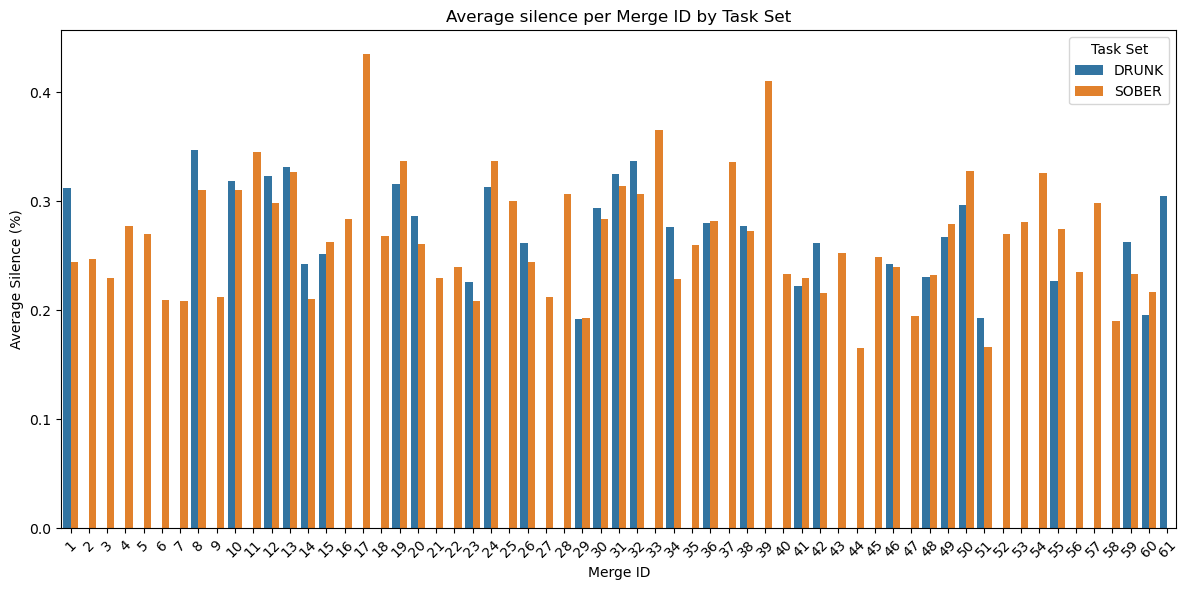

In [17]:
average_silence = df_Train.groupby(['task_set', 'merge_id'])['silent'].mean().reset_index()
average_silence.rename(columns={'silent': 'average_silence'}, inplace=True)

avg_drunk = average_silence[average_silence['task_set'] == 'DRUNK'].sort_values(by='merge_id')
avg_sober = average_silence[average_silence['task_set'] == 'SOBER'].sort_values(by='merge_id')

plt.figure(figsize=(12, 6))
sns.barplot(data=average_silence, x='merge_id', y='average_silence', hue='task_set')

plt.title("Average silence per Merge ID by Task Set")
plt.xlabel("Merge ID")
plt.ylabel("Average Silence (%)")
plt.legend(title="Task Set")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

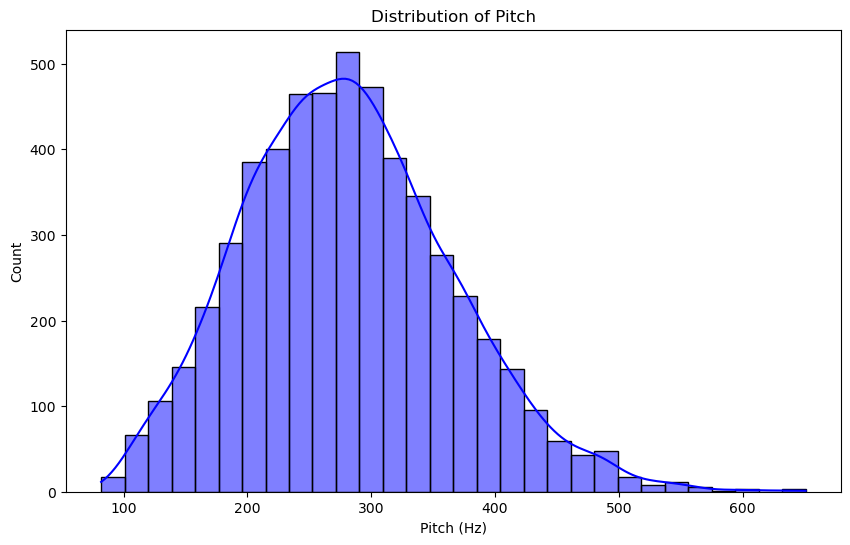

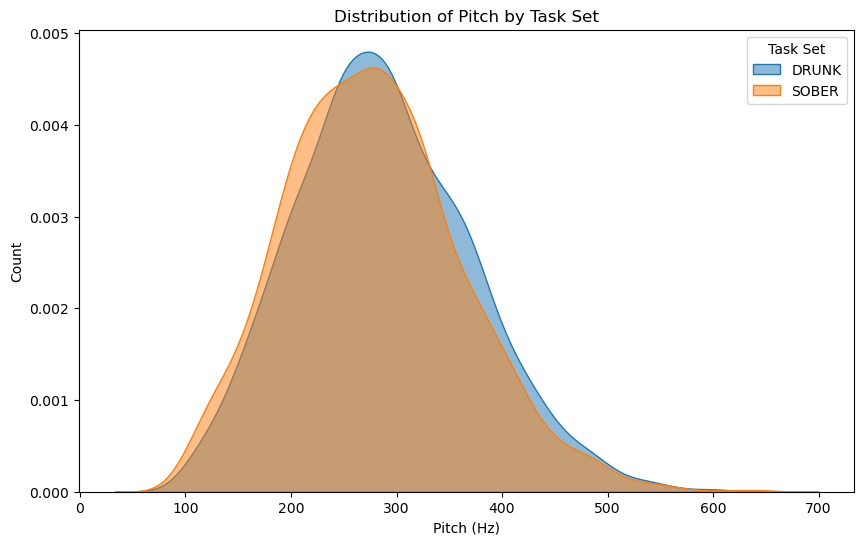

Minimum pitch:  81.87820819356163
Maximum pitch:  650.9937586072691


In [19]:
#Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_Train['pitch'], bins=30, kde=True, edgecolor='black',color='blue')
plt.title('Distribution of Pitch')
plt.xlabel('Pitch (Hz)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))

# Plot each task_set separately to ensure correct legend
for task in df_Train['task_set'].unique():
    subset = df_Train[df_Train['task_set'] == task]
    sns.kdeplot(data=subset, x='pitch', label=task, fill=True, alpha=0.5)

plt.title('Distribution of Pitch by Task Set')
plt.xlabel('Pitch (Hz)')
plt.ylabel('Count')
plt.legend(title='Task Set')

plt.show()


# Print pitch stats
print("Minimum pitch: ", df_Train['pitch'].min())
print("Maximum pitch: ", df_Train['pitch'].max())

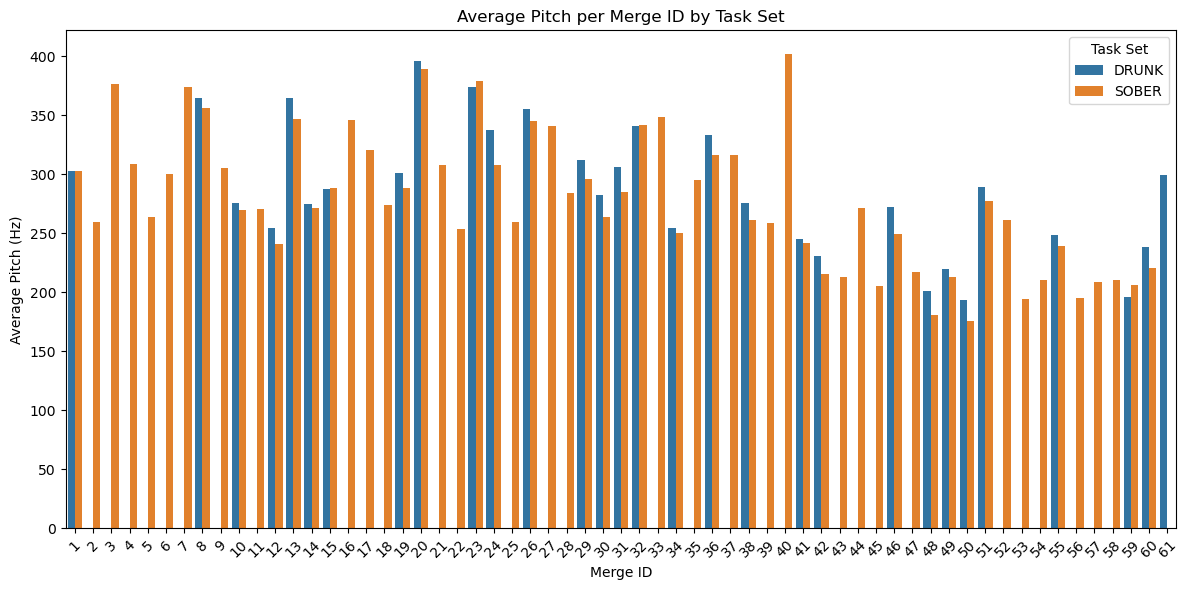

In [18]:
average_pitch = df_Train.groupby(['task_set', 'merge_id'])['pitch'].mean().reset_index()
average_pitch.rename(columns={'pitch': 'average_pitch'}, inplace=True)

avg_drunk = average_pitch[average_pitch['task_set'] == 'DRUNK'].sort_values(by='merge_id')
avg_sober = average_pitch[average_pitch['task_set'] == 'SOBER'].sort_values(by='merge_id')

plt.figure(figsize=(12, 6))
sns.barplot(data=average_pitch, x='merge_id', y='average_pitch', hue='task_set')

plt.title("Average Pitch per Merge ID by Task Set")
plt.xlabel("Merge ID")
plt.ylabel("Average Pitch (Hz)")
plt.legend(title="Task Set")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\nagap\AppData\Local\Temp\ipykernel_19636\1041624644.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='task_set', y='mean', data=rms_stats, palette='Set2')


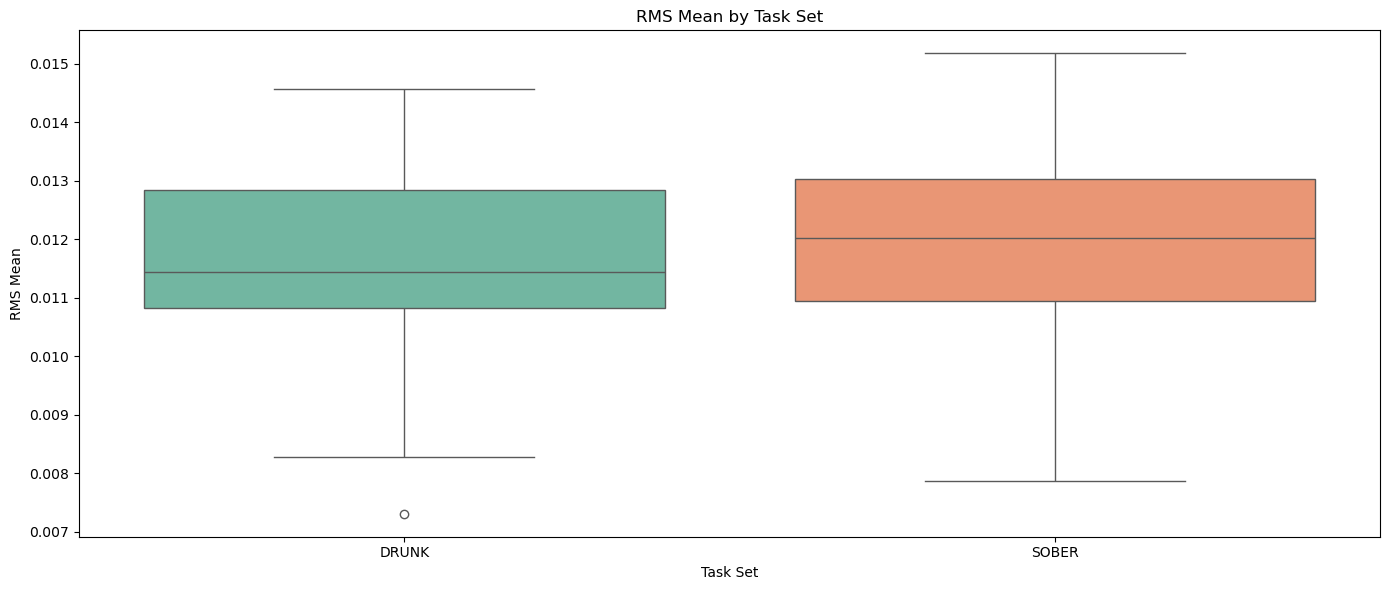

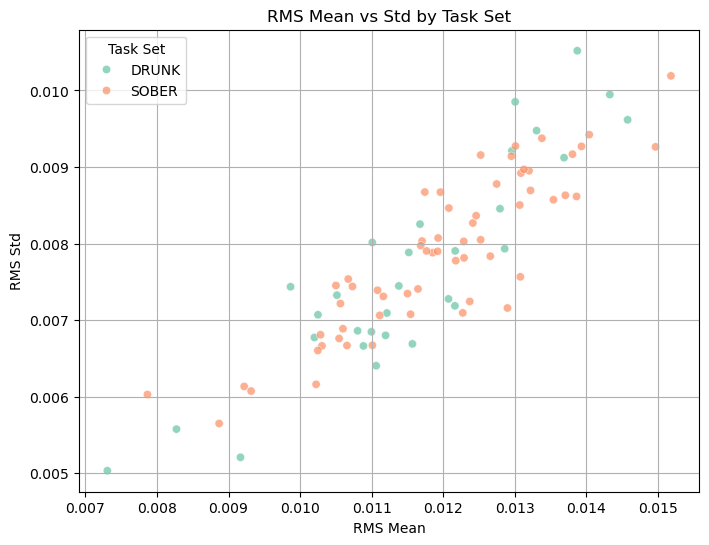

In [ ]:
rms_stats = df_Train.groupby(['task_set', 'merge_id'])['rms_energy'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(14, 6))
# RMS Mean
plt.subplot(1, 1, 1)
sns.boxplot(x='task_set', y='mean', data=rms_stats, palette='Set2')
plt.title('RMS Mean by Task Set')
plt.ylabel('RMS Mean')
plt.xlabel('Task Set')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=rms_stats,
    x='mean',
    y='std',
    hue='task_set',
    palette='Set2',
    alpha=0.7
)

plt.title('RMS Mean vs Std by Task Set')
plt.xlabel('RMS Mean')
plt.ylabel('RMS Std')
plt.legend(title='Task Set')
plt.grid(True)
plt.show()

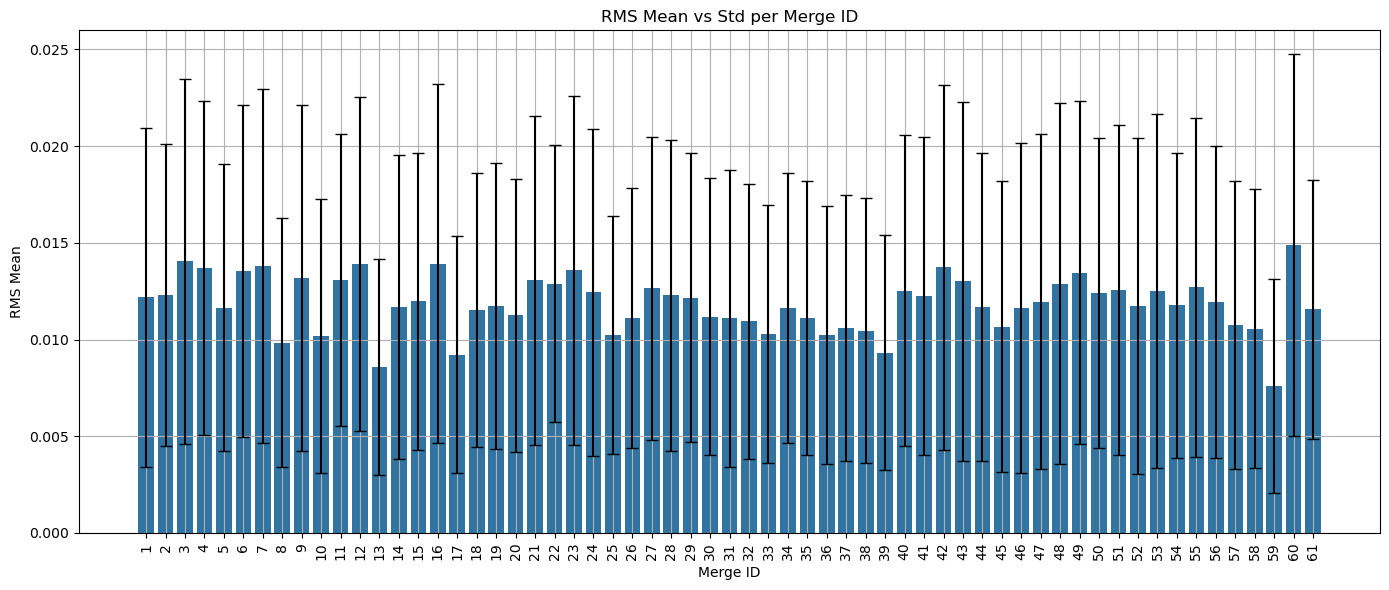

In [36]:
# Compute stats per task_id and task_set
rms_task_stats = df_Train.groupby([ 'merge_id'])['rms_energy'].agg(['mean', 'std']).reset_index()
rms_task_stats.columns = ['merge_id', 'rms_mean', 'rms_std']
rms_task_stats = rms_task_stats.sort_values(by='merge_id')

plt.figure(figsize=(14, 6))
sns.barplot(
    data=rms_task_stats,
    x='merge_id',
    y='rms_mean',
    errorbar=None
)

# Add custom error bars (standard deviation)
for i, row in rms_task_stats.iterrows():
    x = list(rms_task_stats['merge_id']).index(row['merge_id'])
    plt.errorbar(x, row['rms_mean'], yerr=row['rms_std'], fmt='none', c='black', capsize=4)


plt.title('RMS Mean vs Std per Merge ID')
plt.xlabel('Merge ID')
plt.ylabel('RMS Mean')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
df_drunk = df_Train[df_Train['task_set'] == 'DRUNK']
df_sober = df_Train[df_Train['task_set'] == 'SOBER']
print("DRUNK")
print(df_drunk[['rms_energy','rms_std']].describe())
print("\nSOBER")
print(df_sober[['rms_energy','rms_std']].describe())

DRUNK
        rms_energy      rms_std
count  1800.000000  1800.000000
mean      0.011555     0.014996
std       0.007896     0.009911
min       0.000618     0.001008
25%       0.005883     0.007754
50%       0.009443     0.012281
75%       0.015075     0.019594
max       0.060911     0.076228

SOBER
        rms_energy      rms_std
count  3600.000000  3600.000000
mean      0.011951     0.015431
std       0.007998     0.010322
min       0.001148     0.001669
25%       0.005790     0.007404
50%       0.009565     0.012240
75%       0.016475     0.021240
max       0.047485     0.063432


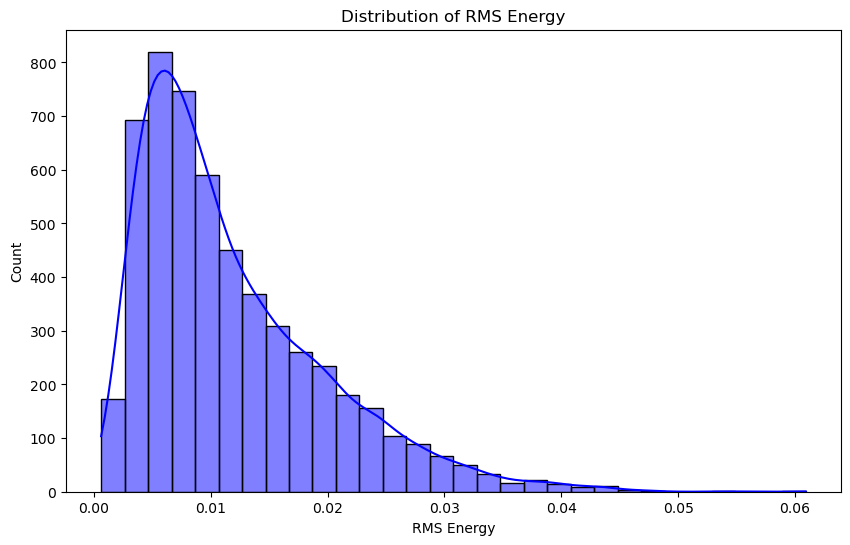

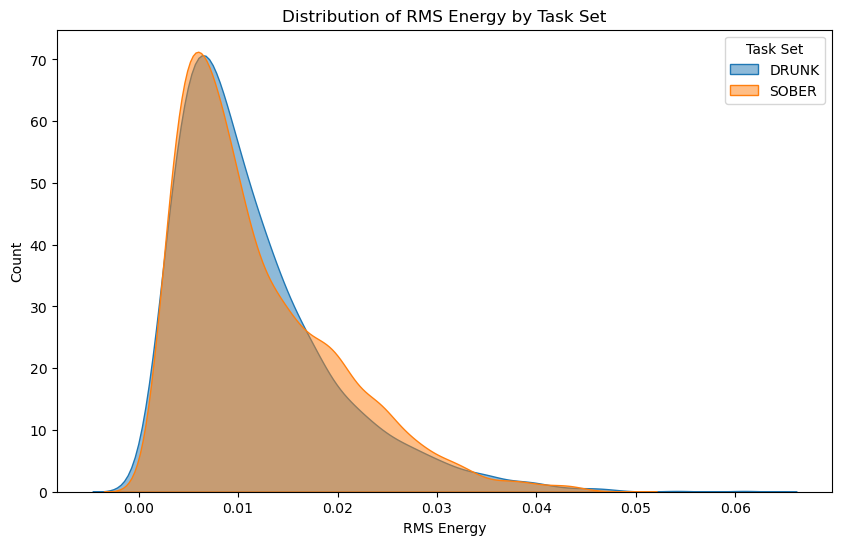

Minimum RMS Energy:  0.0006183417863212526
Maximum RMS Energy:  0.060911186039447784


In [20]:
#Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_Train['rms_energy'], bins=30, kde=True, edgecolor='black',color='blue')
plt.title('Distribution of RMS Energy')
plt.xlabel('RMS Energy')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))

# Plot each task_set separately to ensure correct legend
for task in df_Train['task_set'].unique():
    subset = df_Train[df_Train['task_set'] == task]
    sns.kdeplot(data=subset, x='rms_energy', label=task, fill=True, alpha=0.5)

plt.title('Distribution of RMS Energy by Task Set')
plt.xlabel('RMS Energy')
plt.ylabel('Count')
plt.legend(title='Task Set')

plt.show()


# Print pitch stats
print("Minimum RMS Energy: ", df_Train['rms_energy'].min())
print("Maximum RMS Energy: ", df_Train['rms_energy'].max())

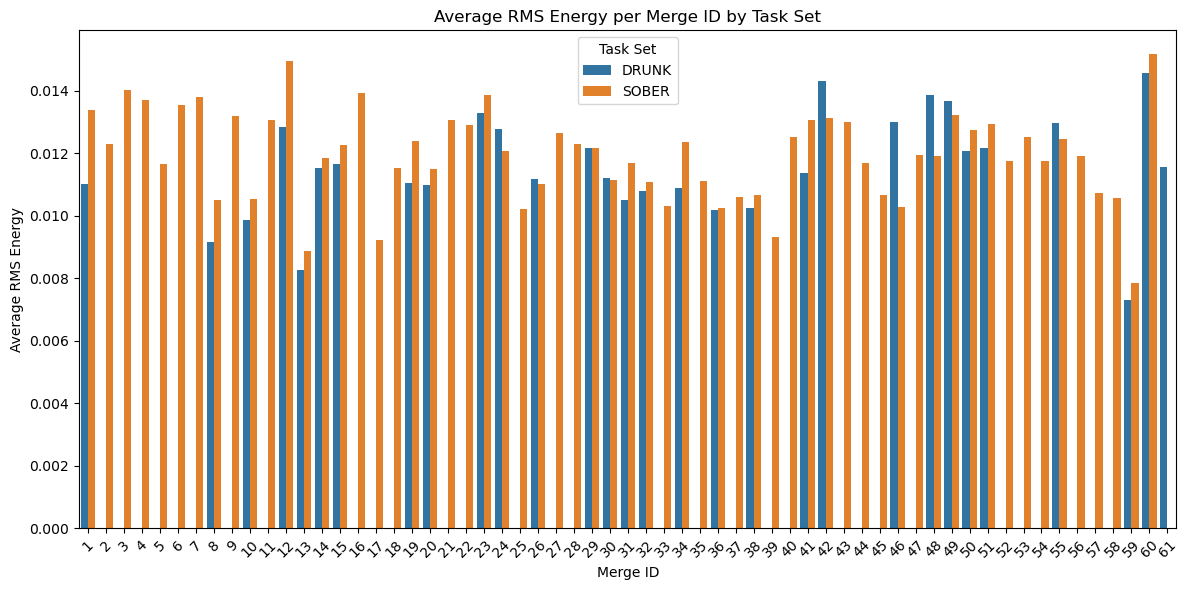

In [21]:
average_rms = df_Train.groupby(['task_set', 'merge_id'])['rms_energy'].mean().reset_index()
average_rms.rename(columns={'rms_energy': 'average_rms'}, inplace=True)

avg_drunk = average_rms[average_rms['task_set'] == 'DRUNK'].sort_values(by='merge_id')
avg_sober = average_rms[average_rms['task_set'] == 'SOBER'].sort_values(by='merge_id')

plt.figure(figsize=(12, 6))
sns.barplot(data=average_rms, x='merge_id', y='average_rms', hue='task_set')

plt.title("Average RMS Energy per Merge ID by Task Set")
plt.xlabel("Merge ID")
plt.ylabel("Average RMS Energy")
plt.legend(title="Task Set")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

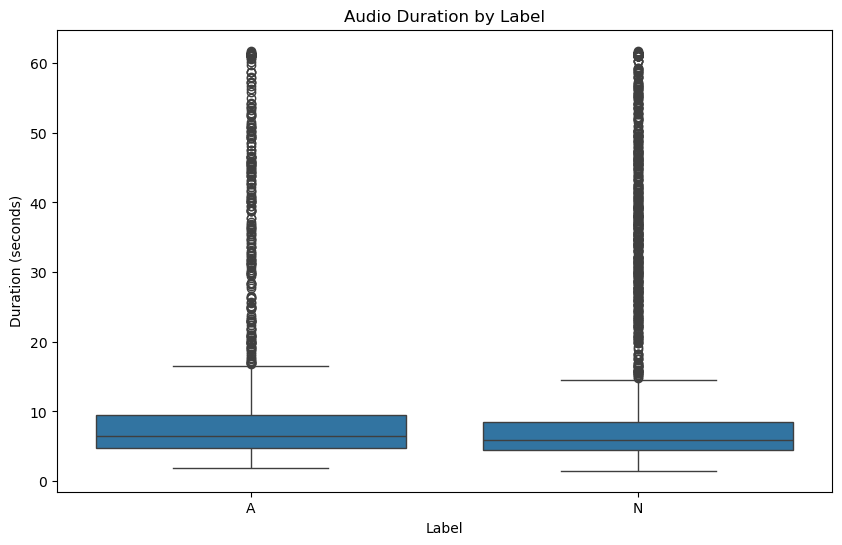

In [22]:
#Comparing durations by label
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='duration', data=df_Train)
plt.title('Audio Duration by Label')
plt.xlabel('Label')
plt.ylabel('Duration (seconds)')
plt.show()

In [23]:
# Print basic stats for each label
print("Basic stats for Drunk audio:")
print_basic_stats(df_Train[df_Train['label'] == 'A'])
print("\nBasic stats for Sober audio:")
print_basic_stats(df_Train[df_Train['label'] == 'N'])

Basic stats for Drunk audio:
Number of samples:  1650
Number of samples per label: 
label
A    1650
Name: count, dtype: int64
Average duration:  11.930804287775716
Median duration:  6.5
Standard deviation of duration:  14.261791372999179
Minimum duration:  1.92
Maximum duration:  61.74

Basic stats for Sober audio:
Number of samples:  3750
Number of samples per label: 
label
N    3750
Name: count, dtype: int64
Average duration:  11.562933333333334
Median duration:  5.92
Standard deviation of duration:  14.637109203656998
Minimum duration:  1.49
Maximum duration:  61.77
